# 01_Metadata_Summary
## 16Sep2026
## Xiaonan Wang

In [1]:
#%matplotlib nbagg
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
from os import listdir
from os.path import isfile, join
import re
import anndata
# import scvi

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(name='gene_cmap', colors=['lightgrey', '#a1a1ce', 'purple', '#301934']) 
sc.settings.set_figure_params(dpi=80, color_map='viridis', vector_friendly=False,  dpi_save=300)

In [2]:
import sys

project_dir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/analysis_v1"

if project_dir not in sys.path:
    sys.path.append(project_dir)

import source

In [2]:
sc.logging.print_header()

Package,Version
numpy,2.4.5
matplotlib,3.10.9
scanpy,1.11.5
pandas,2.3.3
anndata,0.12.14
Component,Info
Python,"3.11.6 | packaged by conda-forge | (main, Oct 3 2023, 10:40:35) [GCC 12.3.0]"
OS,Linux-4.18.0-553.81.1.el8_10.x86_64-x86_64-with-glibc2.28
CPU,"5/64 logical CPU cores, x86_64"
GPU,No GPU found


**Related files**:
- Spatial\Spatial\xenium.h5ad — essential master object; sufficient for AM identification, expression, coordinates, nearest-neighbour analysis, and AT2 communication.
- Spatial\Spatial\myeloid_xenium.h5ad — recommended working subset for AM classification.
- Spatial\Spatial\soapy_obs.csv and soapy_uns.pkl — required only if reusing the published 30 spatial niches.
- Spatial\Spatial\epithelial_xenium.h5ad — useful validation subset for AT2 annotations, but redundant with the master object.

In [3]:
datadir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/data/Spatial/"
outdir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/analysis_v1/write_all/"

## Step0 - Read in Files

In [4]:
x_all = sc.read_h5ad(datadir + "xenium.h5ad")

In [5]:
x_all

AnnData object with n_obs × n_vars = 332063 × 389
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'donor_id', 'core_id', 'tma_id', 'age', 'pmi', 'sex', 'tissue_annotation', 'tech', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'n_counts', 'n_genes', 'celltype_final', 'age_category'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'features'
    uns: 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [15]:
from pathlib import Path
import zipfile
import requests

url = (
    "https://static-content.springer.com/esm/"
    "art%3A10.1038%2Fs41467-026-75427-5/"
    "MediaObjects/41467_2026_75427_MOESM8_ESM.xlsx"
)

path = Path("./41467_2026_75427_MOESM8_ESM.xlsx")

response = requests.get(
    url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=60,
)
response.raise_for_status()

data = response.content

print("HTTP status:", response.status_code)
print("Content type:", response.headers.get("content-type"))
print("Downloaded size:", len(data), "bytes")
print("Header:", data[:20])

if not data.startswith(b"PK"):
    preview = data[:1000].decode("utf-8", errors="replace")
    raise RuntimeError(
        "The server returned something other than XLSX:\n\n"
        + preview
    )

# Write only after validation
path.write_bytes(data)

assert zipfile.is_zipfile(path)
print("Valid XLSX saved:", path)

HTTP status: 200
Content type: application/octet-stream
Downloaded size: 88069 bytes
Header: b'PK\x03\x04\x14\x00\x06\x00\x08\x00\x00\x00!\x00O\x13\xac\x05u\x01'
Valid XLSX saved: 41467_2026_75427_MOESM8_ESM.xlsx


In [26]:
import pandas as pd
from difflib import get_close_matches

def normalize_gene(values):
    return pd.Index(values).astype(str).str.strip().str.upper()

panel = pd.read_excel(
    "./41467_2026_75427_MOESM8_ESM.xlsx",
    sheet_name="Xenium Gene Panel",
)

alias_map = {
    "CDKN1A/P21": "CDKN1A",
    "CDKN2D/P19": "CDKN2D",
    "IL8": "CXCL8",
    "TYROBP/DAP12": "TYROBP",
}

panel["adata_gene"] = (
    panel["Gene"]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace(alias_map)
)

panel["gene_normalized"] = normalize_gene(panel["Gene"])
adata_genes = set(normalize_gene(x_all.var_names))

standard_mask = (
    panel["Note"]
    .astype(str)
    .str.strip()
    .str.casefold()
    .eq("standard lung panel")
)

panel["panel_origin"] = standard_mask.map(
    {
        True: "Standard lung panel",
        False: "Custom ageing panel",
    }
)

print(panel["panel_origin"].value_counts())

panel_origin
Standard lung panel    289
Custom ageing panel    100
Name: count, dtype: int64


In [33]:
panel.head()

,Gene,Ensembl_ID,Annotation,Note,adata_gene,gene_normalized,panel_origin
0,ACE,ENSG00000159640,Capillary cell,Standard lung panel,ACE,ACE,Standard lung panel
1,ACE2,ENSG00000130234,COVID-19,Standard lung panel,ACE2,ACE2,Standard lung panel
2,ACKR1,ENSG00000213088,Vein cell,Standard lung panel,ACKR1,ACKR1,Standard lung panel
3,ADAM17,ENSG00000151694,Classical monocyte,Standard lung panel,ADAM17,ADAM17,Standard lung panel
4,ADAM28,ENSG00000042980,B cell,Standard lung panel,ADAM28,ADAM28,Standard lung panel


In [27]:
panel_origin_map = (
    panel.drop_duplicates("adata_gene")
    .set_index("adata_gene")["panel_origin"]
)

adata_normalized = (
    pd.Index(x_all.var_names)
    .astype(str)
    .str.strip()
    .str.upper()
)

x_all.var["panel_origin"] = (
    pd.Series(adata_normalized, index=x_all.var_names)
    .map(panel_origin_map)
    .to_numpy()
)

x_all.var["is_custom_ageing_gene"] = (
    x_all.var["panel_origin"].eq("Custom ageing panel")
)

display(x_all.var["panel_origin"].value_counts(dropna=False))

panel_origin
Standard lung panel    289
Custom ageing panel     97
NaN                      3
Name: count, dtype: int64

In [28]:
unresolved = x_all.var.loc[
    x_all.var["panel_origin"].isna()
].copy()

unresolved["Gene"] = unresolved.index
display(unresolved)

,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells,features,is_custom_ageing_gene,panel_origin,Gene
features,,,,,,,,,,,
ATM,96740,0.340108,0.292750,78.182671,150807.0,11.923763,96103,ATM,False,NaN,ATM
BPIFB1,8522,0.404617,0.339765,98.078072,179411.0,12.097440,8469,BPIFB1,False,NaN,BPIFB1
LRP6,70521,0.224495,0.202528,84.095722,99543.0,11.508355,70243,LRP6,False,NaN,LRP6


In [30]:
published_ageing_genes = (
    panel.loc[
        panel["panel_origin"].eq("Custom ageing panel"),
        "Gene",
    ]
    .dropna()
    .tolist()
)

assert len(published_ageing_genes) == 100

In [31]:
x_all.var["panel_origin"] = (
    x_all.var["panel_origin"]
    .fillna("Unresolved / actual-data addition")
)

In [35]:
x_all.var_names[x_all.var["is_custom_ageing_gene"]]

Index(['ANXA1', 'APOE', 'APP', 'ATP5F1C', 'CASP1', 'CCL1', 'CCL2', 'CCL3',
       'CCL4', 'CCNA2', 'CCNE2', 'CCR5', 'CD44', 'CD47', 'CD74', 'CDH5',
       'CDK4', 'CDK6', 'CDKN1A', 'CDKN2A', 'CDKN2B', 'CDKN2D', 'CEACAM6',
       'CSF1', 'CSF2', 'CXCL12', 'CXCL2', 'CXCL8', 'CXCR2', 'CXCR4', 'DNAJB1',
       'DPP4', 'E2F1', 'EMP2', 'FLT1', 'FN1', 'FOS', 'FPR3', 'GLB1', 'HGF',
       'HLA-DQB1', 'HLA-E', 'HMGB1', 'HMGB2', 'HSPA8', 'ICAM1', 'IFNG',
       'IGFBP7', 'IL12A', 'IL12B', 'IL1A', 'IL1B', 'IL23A', 'IL6', 'ITGAL',
       'KRT17', 'KRT5', 'KRT8', 'LMNB1', 'LMNB2', 'MAPK1', 'MAPK14', 'MAPK3',
       'MIF', 'MMP1', 'MMP2', 'MMP3', 'MX1', 'MYD88', 'NFKB2', 'PECAM1',
       'PLAU', 'PLAUR', 'PRKN', 'RB1', 'ROR1', 'SELENOH', 'SERPINE1', 'SIRPA',
       'SIRT1', 'SPP1', 'TEK', 'TGFB1', 'TICAM1', 'TLR4', 'TNF', 'TP53',
       'TRAM1', 'TYROBP', 'VEGFA', 'VEGFB', 'VEGFC', 'VEGFD', 'VSIR', 'WIF1',
       'WNT5A', 'WNT7B'],
      dtype='object', name='features')

In [32]:
x_all.var["panel_origin"].value_counts()

panel_origin
Standard lung panel                  289
Custom ageing panel                   97
Unresolved / actual-data addition      3
Name: count, dtype: int64

## Step1 - Metadata Summary

In [6]:
pd.set_option("display.max_rows", None)

In [7]:
meta_cols = [
    "donor_id",
    "core_id",
    "tma_id",
    "age",
    "pmi",
    "sex",
    "tissue_annotation",
]

unique_meta = x_all.obs[meta_cols].drop_duplicates().reset_index(drop=True)

In [8]:
unique_meta.head()

,donor_id,core_id,tma_id,age,pmi,sex,tissue_annotation
0,D11,D11.c1,TMA1,38,4.0,M,V
1,D11,D11.c2,TMA1,38,4.0,M,A
2,D10,D10.c3,TMA1,34,10.0,M,V
3,D10,D10.c2,TMA1,34,10.0,M,A
4,D10,D10.c1,TMA1,34,10.0,M,A


In [17]:
font_files = [
    project_dir+"/arial.ttf",
]

for font_file in font_files:
    fm.fontManager.addfont(font_file)

plt.rcParams["font.family"] = "Arial"

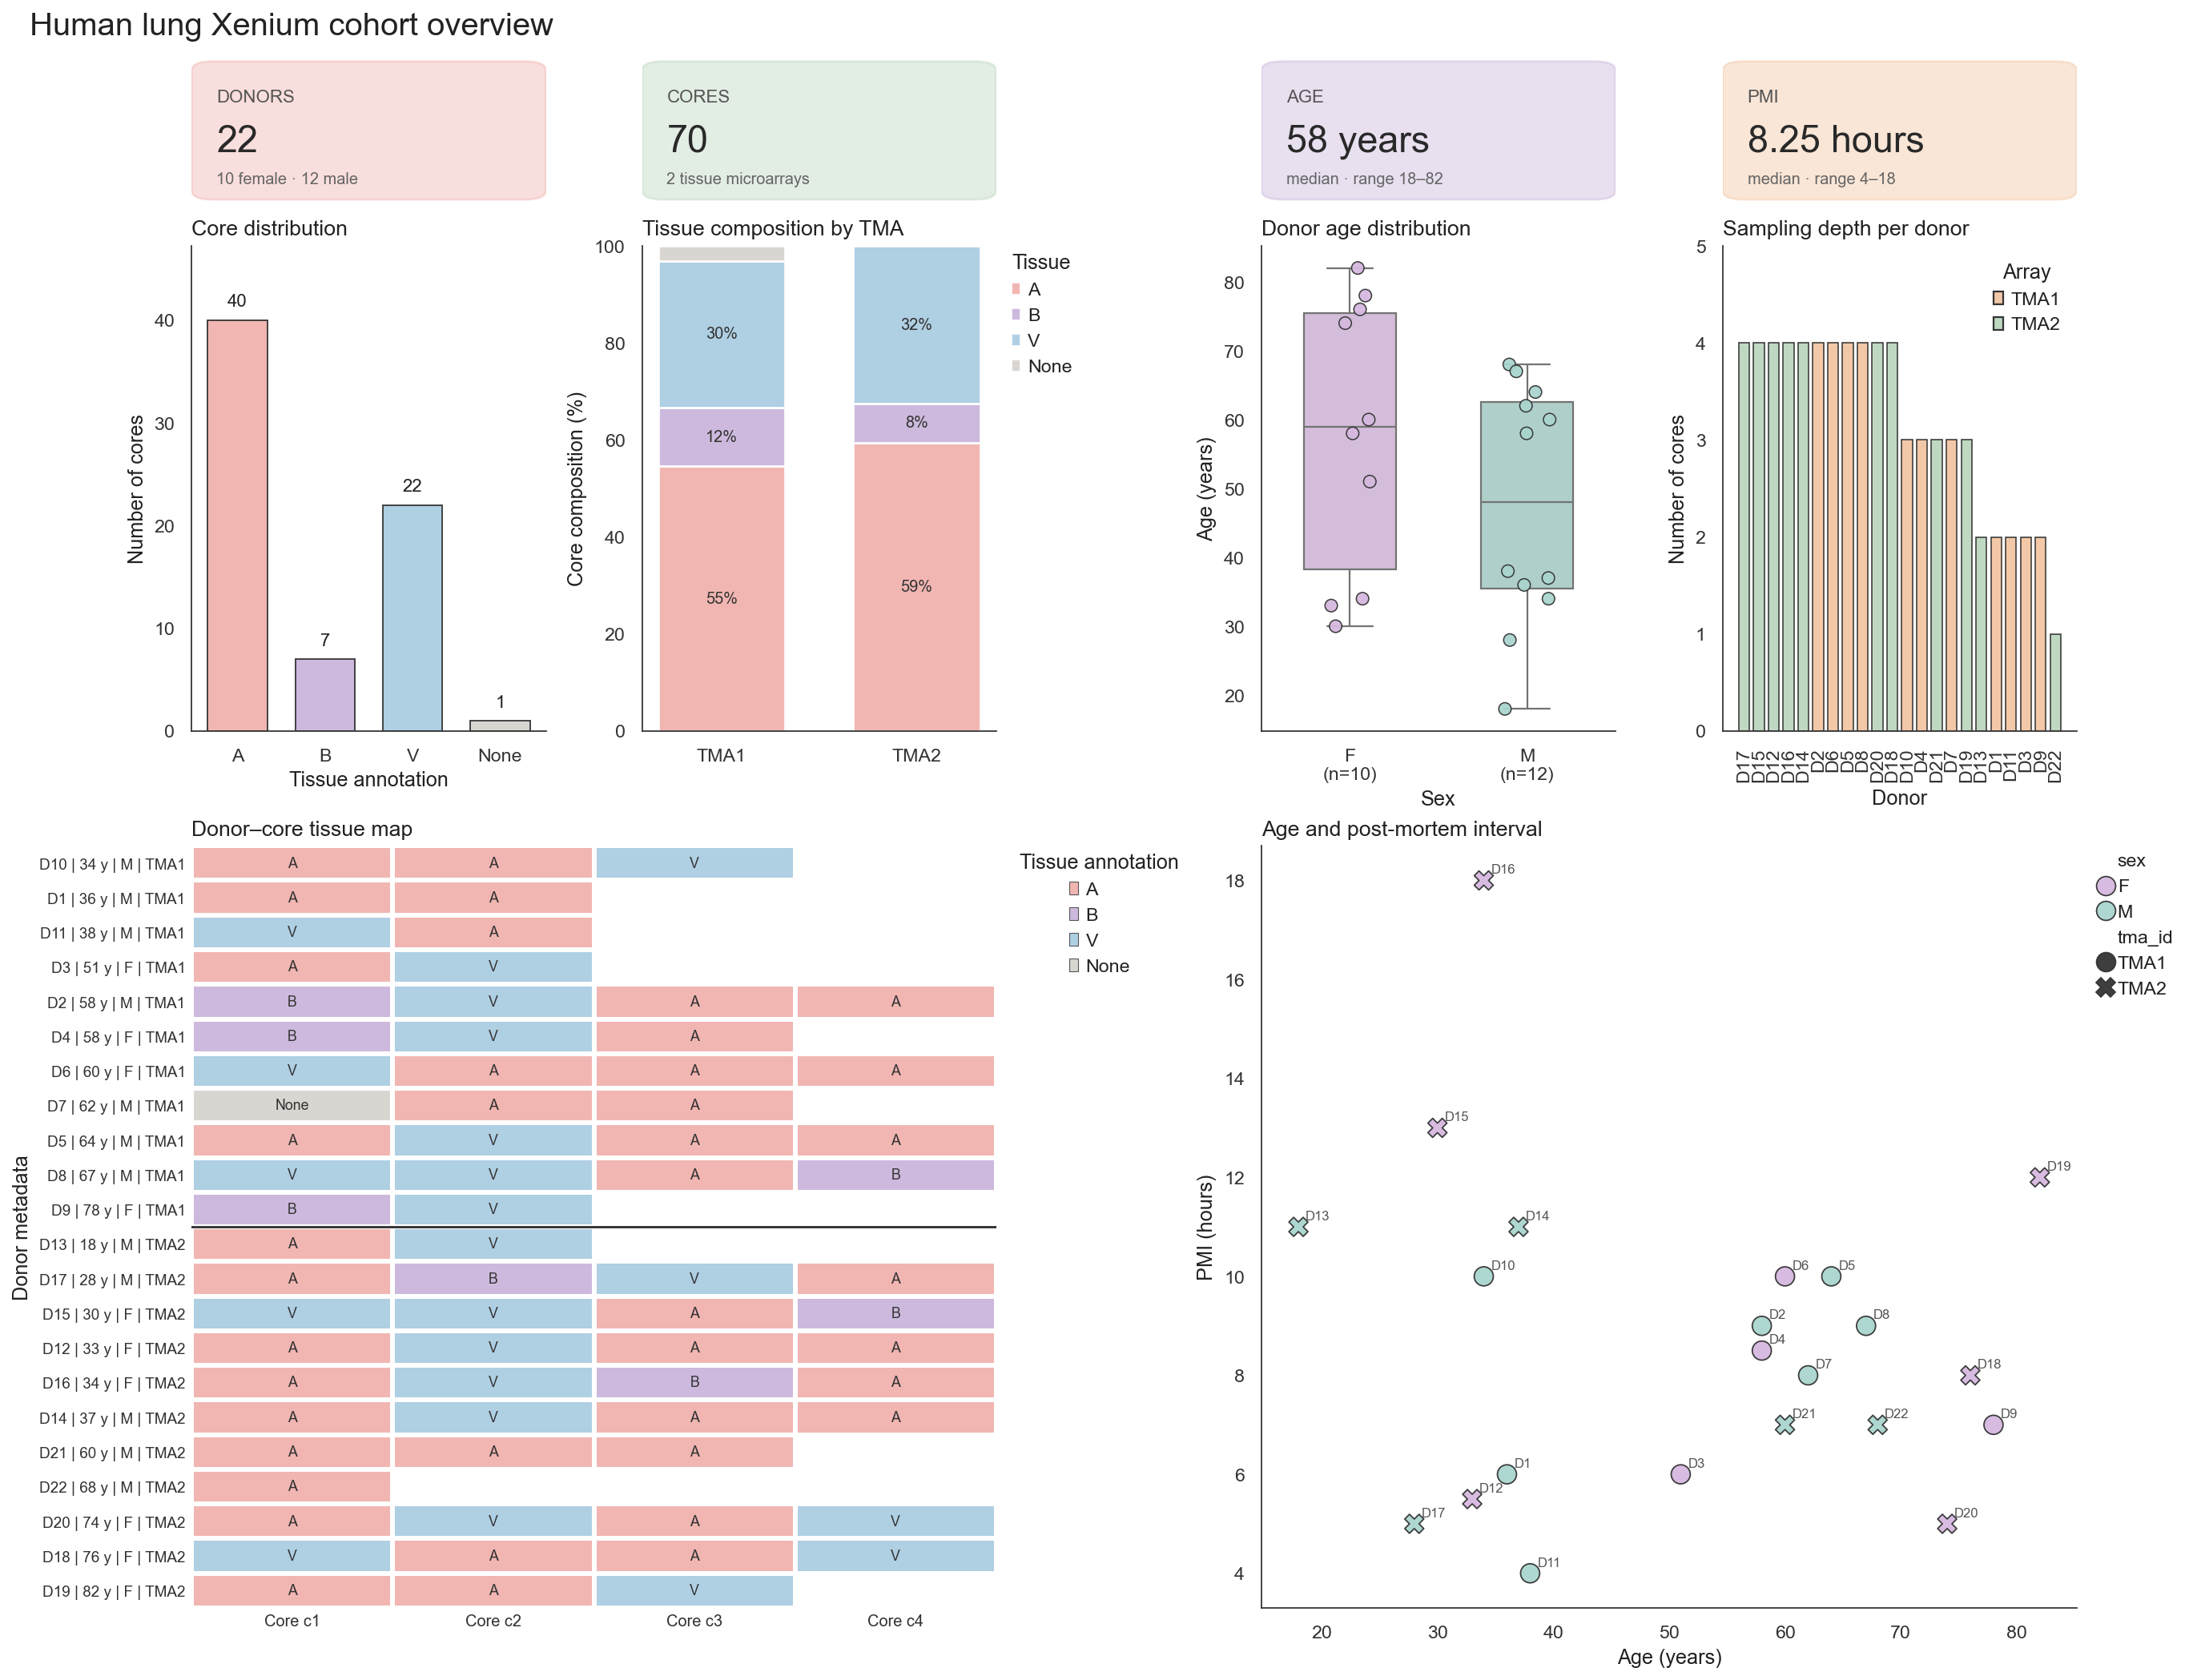

In [20]:
metadata_results = plot_metadata_summary(
    unique_meta,
    tissue_order=("A", "B", "V", "None"),
    save="Xenium_cohort_metadata_summary.pdf",
)

plt.show()

- donor_id: Human donor
- core_id: Individual circular tissue core sampled from a donor - map to donor x tma_id x tissue_annotation -> unique key
- tma_id: Tissue microarray containing the core
- tissue_annotation: ationAnatomical compartment assigned to the entire core
    - A: alveolar/parenchymal region — 40 cores
    - V: vascular region — 22 cores
    - B: bronchial region — 7 cores
    - None: no recorded anatomical annotation

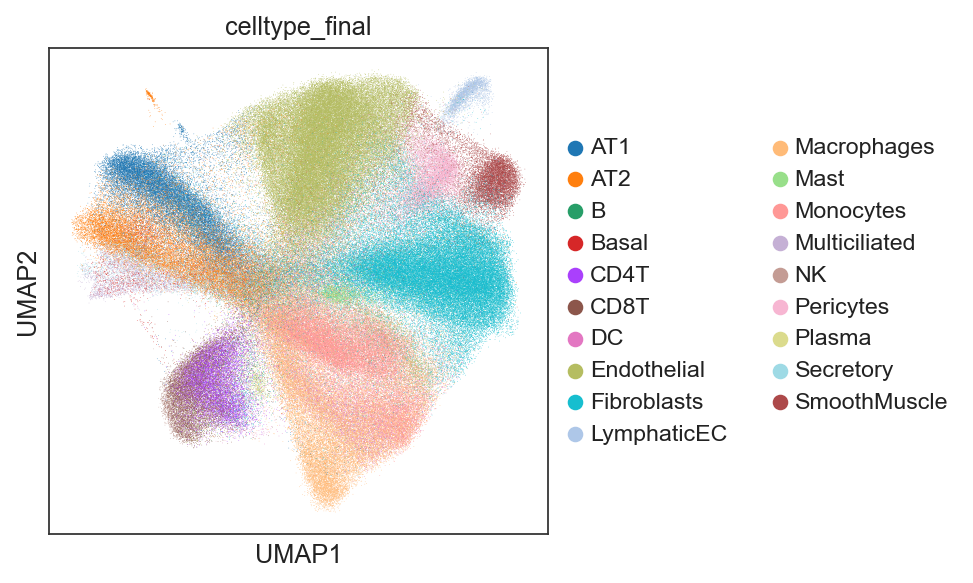

In [21]:
sc.pl.umap(x_all, color='celltype_final', color_map=cmap)

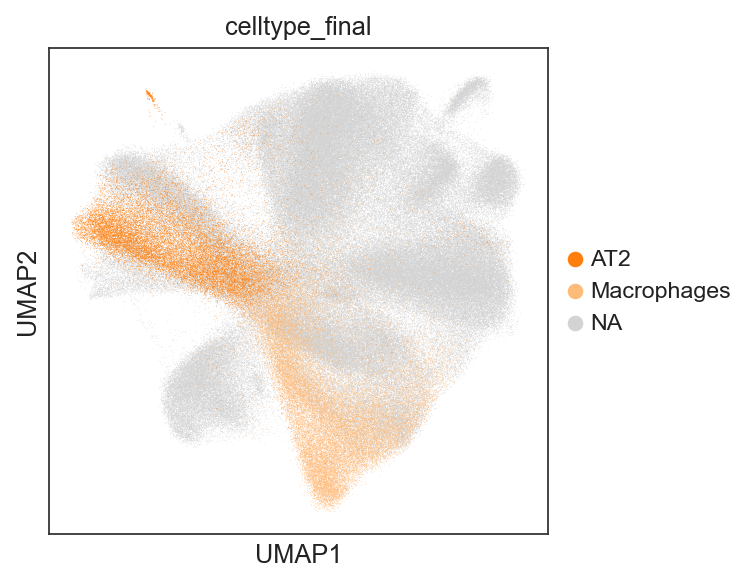

In [23]:
sc.pl.umap(x_all, color='celltype_final', groups=['Macrophages', 'AT2'], color_map=cmap)